# 08 — Tensile tests: E-modulus determination

Thesis figures for the tensile tests (Zwick machine) used to determine the elastic
modulus of each cable. Data lives in `Glasfaser_Tests_E-Mod_Combined.xlsx`:

- **`Ergebnisse`** — final results per measurement (`Emod` [GPa], `Flow`/`Fhigh` [N],
  `Fmax` [N], cross-section `S0` [mm²], ...).
- **`C{n}_{a,b,c}`** — raw curves: `Standardweg` [%] (elongation) vs. `Standardkraft` [N]
  (force), three repeat measurements per cable.

The E-modulus was determined by a **least-squares linear regression** over all points
where `Flow <= F <= Fhigh`, with the window defined as fractions of the maximum force:
40–80 % of `Fmax` for all cables except Cable 6 (20–60 %) and Cable 7 (55–80 %).
(Verified: the least-squares slope reproduces the `Emod` column of `Ergebnisse` to
4 decimals; a simple secant through the two window points does not.)

One figure per cable: the three measured curves (distinguished by linestyle),
the regression window end points, the regression line, and the resulting E-moduli.

> If reading the file raises `PermissionError`, close the workbook in Excel first.

In [22]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ldv_analysis import paper
from ldv_analysis.config import CABLE_COLORS   # C1 … C7 thesis colour code

paper.apply_paper_style()

XLSX = Path(r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Experiment2\Glasfaser_Tests_E-Mod_Combined.xlsx")

MEAS_STYLES = {"a": "-", "b": "--", "c": ":"}   # linestyle per repeat measurement

# Post-peak display: plot beyond Fmax until the force has dropped by this
# fraction of Fmax (0.0 = cut exactly at the peak, None = full recorded curve).
POST_PEAK_DROP = 0.15

## Read the data

`Ergebnisse` has two header blocks (the C4 block carries extra columns `a0`, `b0`),
so the columns are mapped from whichever header row precedes each result row.

In [23]:
LABEL_RE = re.compile(r"^C(\d)_([abc])$")


def read_results(xlsx):
    """Parse the 'Ergebnisse' sheet into a tidy DataFrame indexed by e.g. 'C1_a'."""
    raw = pd.read_excel(xlsx, sheet_name="Ergebnisse", header=None)
    colmap, rows = {}, {}
    for _, r in raw.iterrows():
        vals = r.tolist()
        if "Emod" in [str(v).strip() for v in vals]:          # header row -> new column map
            colmap = {j: str(v).strip() for j, v in enumerate(vals) if isinstance(v, str)}
            continue
        m = LABEL_RE.match(str(vals[0]).strip())
        if m and colmap:
            rows[m.group(0)] = {name: vals[j] for j, name in colmap.items()}
    df = pd.DataFrame(rows).T
    df.index.name = "measurement"
    df["cable"] = df.index.str.slice(0, 2)                    # 'C1' ... 'C7'
    df["rep"] = df.index.str.slice(3, 4)                      # 'a' / 'b' / 'c'
    for c in ("Emod", "Fhigh", "Flow", "Fmax", "S0"):
        df[c] = pd.to_numeric(df[c])
    return df


def read_curve(xlsx, sheet):
    """Raw curve of one measurement: elongation w [%], force f [N]."""
    raw = pd.read_excel(xlsx, sheet_name=sheet, header=None, skiprows=3)
    w = pd.to_numeric(raw[0], errors="coerce").to_numpy()
    f = pd.to_numeric(raw[1], errors="coerce").to_numpy()
    ok = np.isfinite(w) & np.isfinite(f)
    return w[ok], f[ok]


results = read_results(XLSX)
curves = {name: read_curve(XLSX, name) for name in results.index}
results[["Emod", "Flow", "Fhigh", "Fmax", "S0"]]

,Emod,Flow,Fhigh,Fmax,S0
measurement,,,,,
C2_a,24.535264,400.962183,801.924365,1002.405457,11.341149
C2_b,30.947159,330.877881,661.755762,827.194702,11.341149
C2_c,30.382303,355.474219,710.948437,888.685547,11.341149
C3_a,11.996223,231.352905,462.705811,578.382263,11.341149
C3_b,12.287513,263.874634,527.749268,659.686584,11.341149
C3_c,10.105964,402.201880,804.403760,1005.504700,11.341149
C6_a,6.520255,109.977844,329.933533,549.889221,4.154756
C6_b,7.337762,127.335522,382.006567,636.677612,4.154756
C6_c,6.496687,114.614111,343.842334,573.070557,4.154756


## Regression helpers

The window end points are found on the **loading branch** (up to the first force
maximum) by linear interpolation of the `Flow`/`Fhigh` crossings; the regression
line is the least-squares fit over all loading-branch points inside the window —
exactly the fit the E-moduli in `Ergebnisse` come from.

In [24]:
def force_crossing(w, f, thr):
    """Elongation at which the loading curve first reaches force `thr` (interpolated)."""
    i = int(np.argmax(f >= thr))
    if i == 0:
        return w[0]
    return w[i - 1] + (thr - f[i - 1]) / (f[i] - f[i - 1]) * (w[i] - w[i - 1])


def regression(name):
    """Regression data for one measurement.

    Returns the loading-branch peak index, window end points, least-squares
    line and the E-modulus recomputed from the fit (cross-check vs 'Ergebnisse').
    """
    w, f = curves[name]
    r = results.loc[name]
    ipk = int(np.argmax(f))
    wl, fl = w[: ipk + 1], f[: ipk + 1]                       # loading branch
    w_lo = force_crossing(wl, fl, r.Flow)
    w_hi = force_crossing(wl, fl, r.Fhigh)
    sel = (fl >= r.Flow) & (fl <= r.Fhigh)
    slope, offs = np.polyfit(wl[sel], fl[sel], 1)             # F = slope*w + offs
    E_fit = slope / r.S0 * 100 / 1000                         # N/% -> GPa
    return dict(w_lo=w_lo, w_hi=w_hi, slope=slope, offs=offs, E_fit=E_fit,
                ipk=ipk, pct_lo=r.Flow / r.Fmax * 100, pct_hi=r.Fhigh / r.Fmax * 100)


# cross-check: the fit must reproduce the Emod column
chk = pd.DataFrame({n: dict(E_ref=results.loc[n, "Emod"], E_fit=regression(n)["E_fit"])
                    for n in results.index}).T
assert np.allclose(chk.E_ref, chk.E_fit, rtol=1e-4), "regression does not reproduce Ergebnisse"
chk.round(4)

,E_ref,E_fit
C2_a,24.5353,24.5353
C2_b,30.9472,30.9472
C2_c,30.3823,30.3823
C3_a,11.9962,11.9962
C3_b,12.2875,12.2875
C3_c,10.1060,10.1060
C6_a,6.5203,6.5203
C6_b,7.3378,7.3378
C6_c,6.4967,6.4967
C1_a,9.7390,9.7390


## Figures — one per cable

Three repeats share the axes of one figure; linestyle distinguishes the repeats,
the cable colour follows the (corrected) thesis colour code. Thin black lines mark
the regression fits, open circles their end points at the lower/upper force bound.

saved: emod_tensile_cable1.png, emod_tensile_cable1.pdf
[caption] Tensile test of Cable 1: three repeat measurements (a/b/c). The E-modulus is the least-squares fit between 40 % and 80 % of the maximum force.


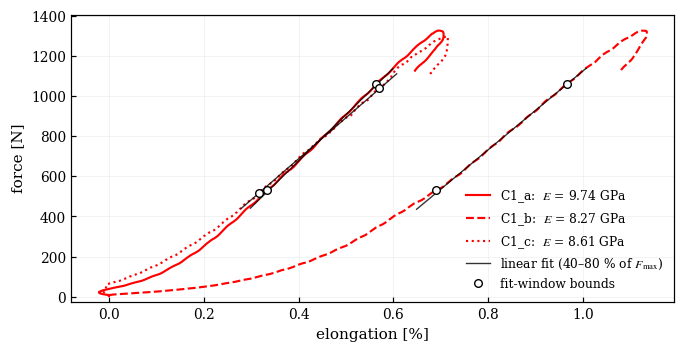

saved: emod_tensile_cable2.png, emod_tensile_cable2.pdf
[caption] Tensile test of Cable 2: three repeat measurements (a/b/c). The E-modulus is the least-squares fit between 40 % and 80 % of the maximum force.


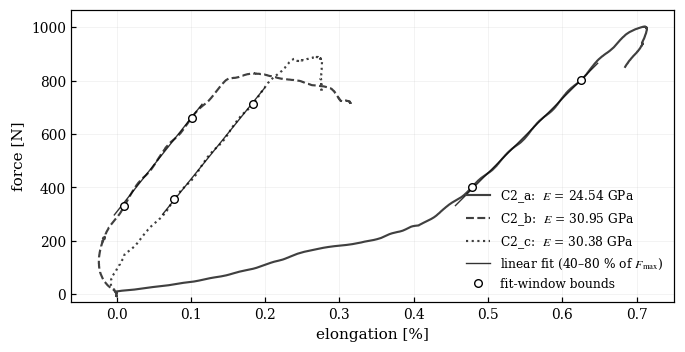

saved: emod_tensile_cable3.png, emod_tensile_cable3.pdf
[caption] Tensile test of Cable 3: three repeat measurements (a/b/c). The E-modulus is the least-squares fit between 40 % and 80 % of the maximum force.


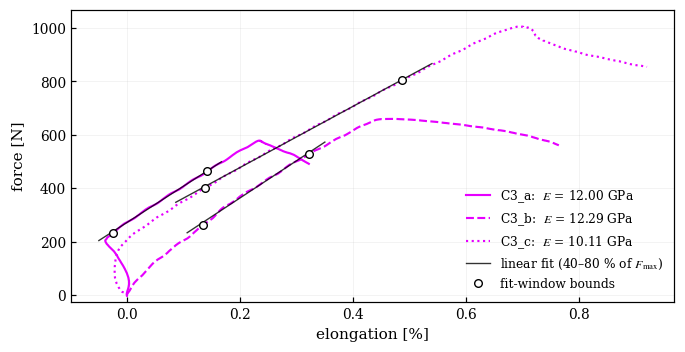

saved: emod_tensile_cable4.png, emod_tensile_cable4.pdf
[caption] Tensile test of Cable 4: three repeat measurements (a/b/c). The E-modulus is the least-squares fit between 40 % and 80 % of the maximum force.


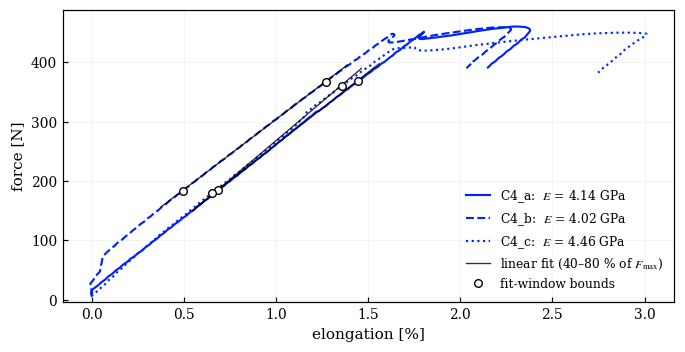

saved: emod_tensile_cable5.png, emod_tensile_cable5.pdf
[caption] Tensile test of Cable 5: three repeat measurements (a/b/c). The E-modulus is the least-squares fit between 40 % and 80 % of the maximum force.


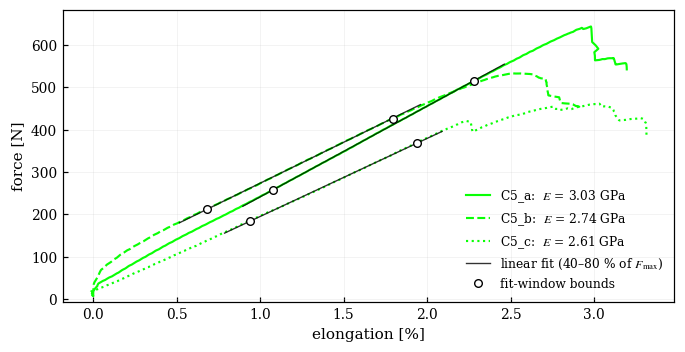

saved: emod_tensile_cable6.png, emod_tensile_cable6.pdf
[caption] Tensile test of Cable 6: three repeat measurements (a/b/c). The E-modulus is the least-squares fit between 20 % and 60 % of the maximum force.


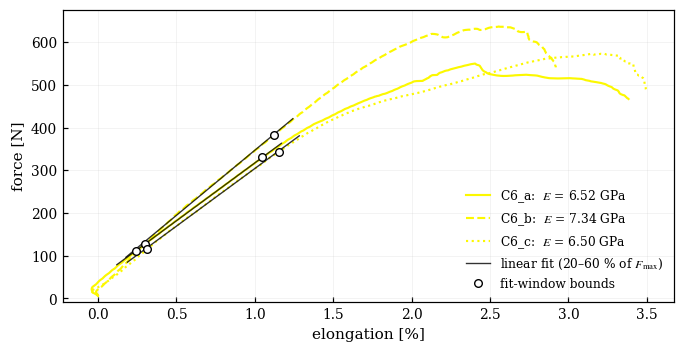

saved: emod_tensile_cable7.png, emod_tensile_cable7.pdf
[caption] Tensile test of Cable 7: three repeat measurements (a/b/c). The E-modulus is the least-squares fit between 55 % and 80 % of the maximum force.


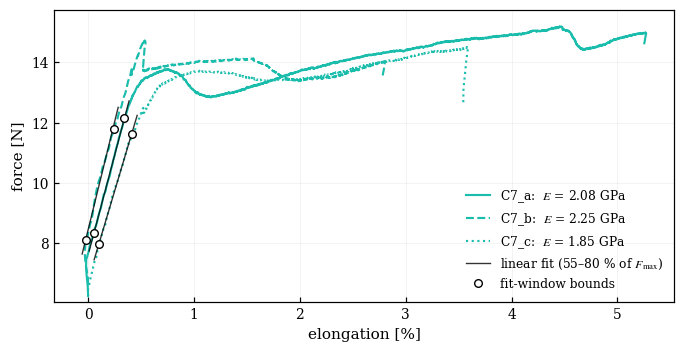

In [25]:
def plot_cable(n, save=True):
    cable_id = f"C{n}"
    color = CABLE_COLORS[cable_id]
    reps = results[results.cable == cable_id].sort_values("rep")

    fig, ax = paper.paper_figure(width="full",
                                 height=0.52 * paper.STYLE["width_full"])
    reg0 = None
    for name, r in reps.iterrows():
        w, f = curves[name]
        reg = regression(name)
        reg0 = reg0 or reg
        if POST_PEAK_DROP is not None:                   # cut shortly after the break
            post = f[reg["ipk"]:] < (1 - POST_PEAK_DROP) * f[reg["ipk"]]
            iend = reg["ipk"] + (int(np.argmax(post)) if post.any() else post.size - 1)
            w, f = w[: iend + 1], f[: iend + 1]
        ax.plot(w, f, ls=MEAS_STYLES[r.rep], color=color,
                label=f"{name}:  $E$ = {r.Emod:.2f} GPa")
        # least-squares regression line across the window (slightly extended)
        pad = 0.15 * (reg["w_hi"] - reg["w_lo"])
        wr = np.array([reg["w_lo"] - pad, reg["w_hi"] + pad])
        ax.plot(wr, reg["slope"] * wr + reg["offs"], color="k", lw=0.9,
                alpha=0.8, zorder=3)
        # window end points on the measured curve
        ax.plot([reg["w_lo"], reg["w_hi"]], [r.Flow, r.Fhigh], "o",
                ms=paper.STYLE["marker_size"], mfc="white", mec="k", mew=0.9, zorder=4)

    # legend entries for the fit elements (once, not per repeat)
    ax.plot([], [], color="k", lw=0.9, alpha=0.8,
            label=f"linear fit ({reg0['pct_lo']:.0f}–{reg0['pct_hi']:.0f} % of $F_\\mathrm{{max}}$)")
    ax.plot([], [], "o", ms=paper.STYLE["marker_size"], mfc="white", mec="k", mew=0.9,
            label="fit-window bounds")

    # Add grid
    ax.grid(visible=True, which="major", axis="both", color="0.8", lw=0.5, ls="-")

    paper.style_axis(ax, xlabel="elongation [%]", ylabel="force [N]",
                     legend=True, legend_kw=dict(loc="lower right"))
    paper.add_headroom(ax, frac=0.06, skip_linestyles=())
    if save:
        paper.save_paper_fig(fig, f"emod_tensile_cable{n}")
    paper.caption_note(
        f"Tensile test of cable {cable_id}: three repeat measurements (a/b/c). The E-modulus is "
        f"the least-squares fit between {reg0['pct_lo']:.0f} % and {reg0['pct_hi']:.0f} % "
        f"of the maximum force."
    )
    return fig


for n in range(1, 8):
    plot_cable(n)
    plt.show()

## Summary — E-modulus per cable

In [26]:
summary = (results.groupby("cable")["Emod"]
           .agg(["mean", "std"])
           .rename(columns={"mean": "E_mean [GPa]", "std": "E_std [GPa]"}))
summary.round(3)

,E_mean [GPa],E_std [GPa]
cable,,
C1,8.872,0.770
C2,28.622,3.550
C3,11.463,1.184
C4,4.207,0.228
C5,2.794,0.217
C6,6.785,0.479
C7,2.058,0.198
